In [12]:
INDIA_PROJECTED_CRS = "24378"

In [13]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

# Setup

In [14]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [16]:
def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    
    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a,i] *= np.linspace(0.2, 1, a)
    ret[a:,3] *= np.linspace(1, 0.3, b)
    
    return ret[:N]  # Return only the requested number of colors

In [17]:
from gridsample.utils import create_ids, save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [18]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels" / "v4"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

# 0. Load cleaned khasras

In [51]:
# Ashok Nagar
ashok_nagar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "ashok_nagar_cleaned_khasras.parquet")
ashok_nagar_gdf

,geometry,FID,Area_ha,parcel_id,districtc,tehsilcode,villageh,village_name,bhucode,Name,...,ownername,column12in,noiyat,landtype,GIS_Area_h,teh_nm_e,ccode11,lgd_gp_cd,khasra_id,Cluster
0,"MULTIPOLYGON (((77.71443 24.38757, 77.71444 24...",0,87.439442,ASKN_7,459,03686,महु आलमपुर,Mahu alampur,40010200063281,72,...,(शासकीय),,पठार 4.4110,शासकीय,4.068589,Ashoknagar,500500,131872,4001020006328172,Cluster1
1,"MULTIPOLYGON (((77.71443 24.38757, 77.71407 24...",1,87.439442,ASKN_7,459,03686,महु आलमपुर,Mahu alampur,40010200063281,71,...,(शासकीय),,पठार 5.0170,शासकीय,5.065853,Ashoknagar,500500,131872,4001020006328171,Cluster1
2,"MULTIPOLYGON (((77.72160 24.38990, 77.72142 24...",2,87.439442,ASKN_7,459,03686,महु आलमपुर,Mahu alampur,40010200063281,50,...,(शासकीय),,पठार 5.0170,शासकीय,4.983981,Ashoknagar,500500,131872,4001020006328150,Cluster1
3,"MULTIPOLYGON (((77.71978 24.38991, 77.71959 24...",3,87.439442,ASKN_7,459,03686,महु आलमपुर,Mahu alampur,40010200063281,49,...,(शासकीय),,NAपठार 5.0170,शासकीय,5.190179,Ashoknagar,500500,131872,4001020006328149,Cluster1
4,"MULTIPOLYGON (((77.71797 24.38994, 77.71754 24...",4,87.439442,ASKN_7,459,03686,महु आलमपुर,Mahu alampur,40010200063281,48,...,(शासकीय),,NAपठार 5.0180,शासकीय,4.575256,Ashoknagar,500500,131872,4001020006328148,Cluster1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,"MULTIPOLYGON (((77.85647 24.70911, 77.85646 24...",344,94.224039,ASKN_49,459,03684,शाहपुर,Shahpur,40030200037127,354,...,(शासकीय),,वीड़ 0.8670,शासकीय,0.858895,Ishagarh,500092,132015,40030200037127354,Cluster0
343,"MULTIPOLYGON (((77.85645 24.70830, 77.85648 24...",345,94.224039,ASKN_49,459,03684,शाहपुर,Shahpur,40030200037127,355,...,(शासकीय),,कदीम 0.0420,शासकीय,0.050155,Ishagarh,500092,132015,40030200037127355,Cluster0
344,"MULTIPOLYGON (((77.85743 24.70827, 77.85696 24...",346,94.224039,ASKN_49,459,03684,शाहपुर,Shahpur,40030200037127,399,...,(शासकीय),,वीड़ का.का. 0.8260,शासकीय,0.86825,Ishagarh,500092,132015,40030200037127399,Cluster0
345,"MULTIPOLYGON (((77.85831 24.70821, 77.85815 24...",347,94.224039,ASKN_49,459,03684,शाहपुर,Shahpur,40030200037127,400,...,(शासकीय),,वीड़ 0.9410,शासकीय,0.913765,Ishagarh,500092,132015,40030200037127400,Cluster0


In [70]:
LOCATION = "Ashok Nagar"
ashok_nagar_gdf.rename(columns={"uid": "khasra_id"}, inplace=True)
gdf_with_parcel_id = ashok_nagar_gdf.to_crs(INDIA_PROJECTED_CRS).reset_index(drop=True)[
    [
        "geometry",
        "Name",
        "khasra_id",
        "village_name",
        "parcel_id"
    ]
]

In [71]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / LOCATION / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [72]:
gdf_with_parcel_id["Khasra Area (ha)"] = gdf_with_parcel_id.area / 10_000

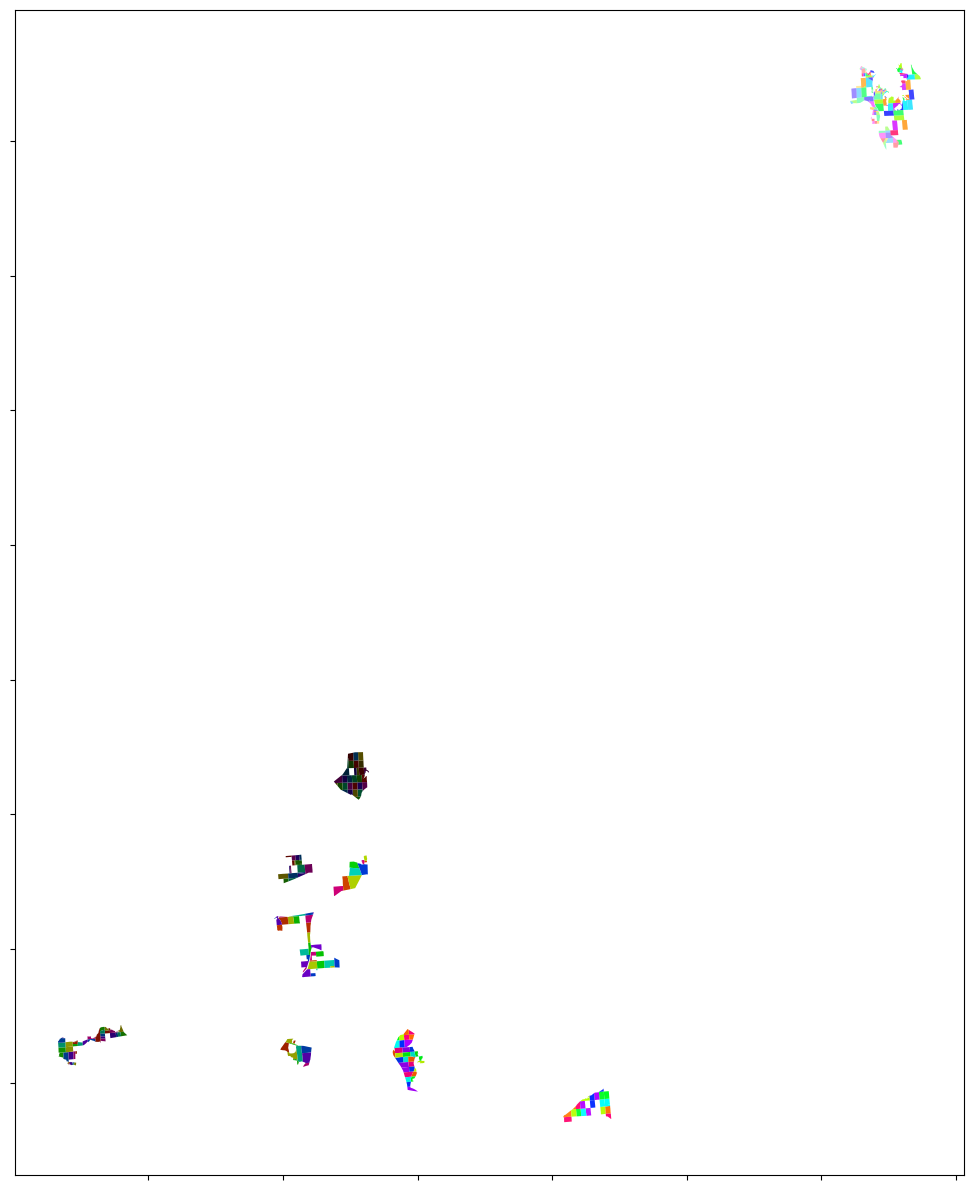

In [73]:
ax = gdf_with_parcel_id.plot(
    column="khasra_id",
    cmap=ListedColormap(generate_colormap(len(gdf_with_parcel_id))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

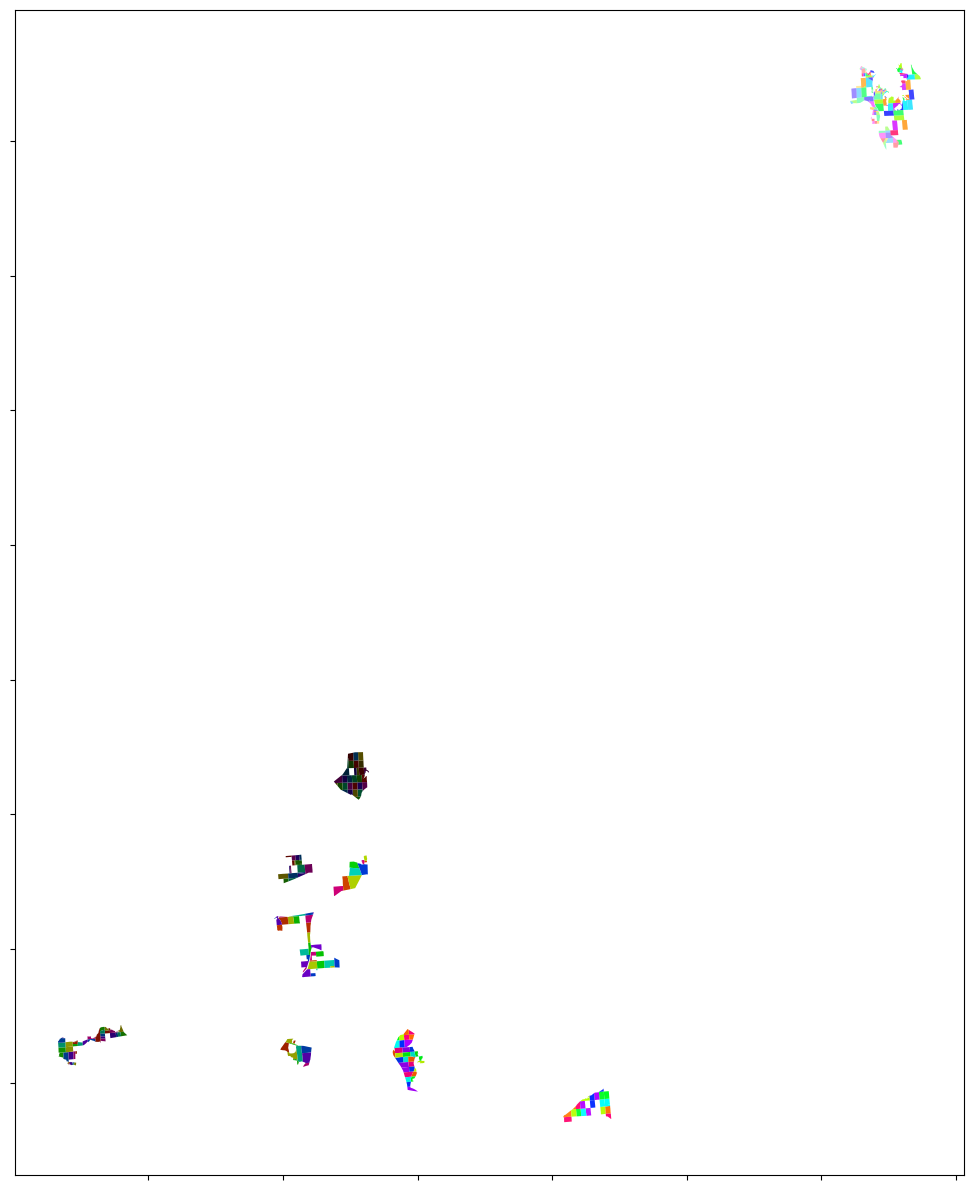

In [75]:
ax = gdf_with_parcel_id.plot(
    column="khasra_id",
    cmap=ListedColormap(generate_colormap(len(gdf_with_parcel_id))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

### Make parcel-level gdf

In [155]:
from utils import get_closest_parcels, get_intra_parcel_distance_stats

In [156]:
parcel_gdf = gdf_with_parcel_id.dissolve(by="parcel_id")
parcel_gdf = parcel_gdf.drop(columns=["khasra_id", "Khasra Area (ha)"])
parcel_gdf = parcel_gdf.reset_index()

In [157]:
parcel_gdf.loc[:, "Original Parcel Area (ha)"] = parcel_gdf["geometry"].area / 10_000

In [158]:
# add how many khasras are inside
khasra_counts_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].count()
parcel_gdf["Khasra Count"] = parcel_gdf["parcel_id"].map(khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
khasra_ids_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].apply(list).astype(str)
parcel_gdf["Khasra IDs"] = parcel_gdf["parcel_id"].map(khasra_ids_series)

In [159]:
# Calculate minimum distances and closest parcel_ids
min_distances, closest_ids = get_closest_parcels(parcel_gdf, parcel_id_col="parcel_id")

# Add the results as new columns
parcel_gdf.loc[:, "Closest Parcel Distance (m)"] = min_distances
parcel_gdf.loc[:, "Closest Parcel ID"] = closest_ids

In [160]:
# intra_distances_df = get_intra_parcel_distance_stats(
#     G_filtered_with_parcel_id,
#     parcel_gdf["parcel_id"].unique(),
#     parcel_id_col="parcel_id",
# )
# parcel_gdf = parcel_gdf.join(
#     intra_distances_df.set_index("parcel_id").drop(columns="raw_distances"),
#     on="parcel_id",
# )

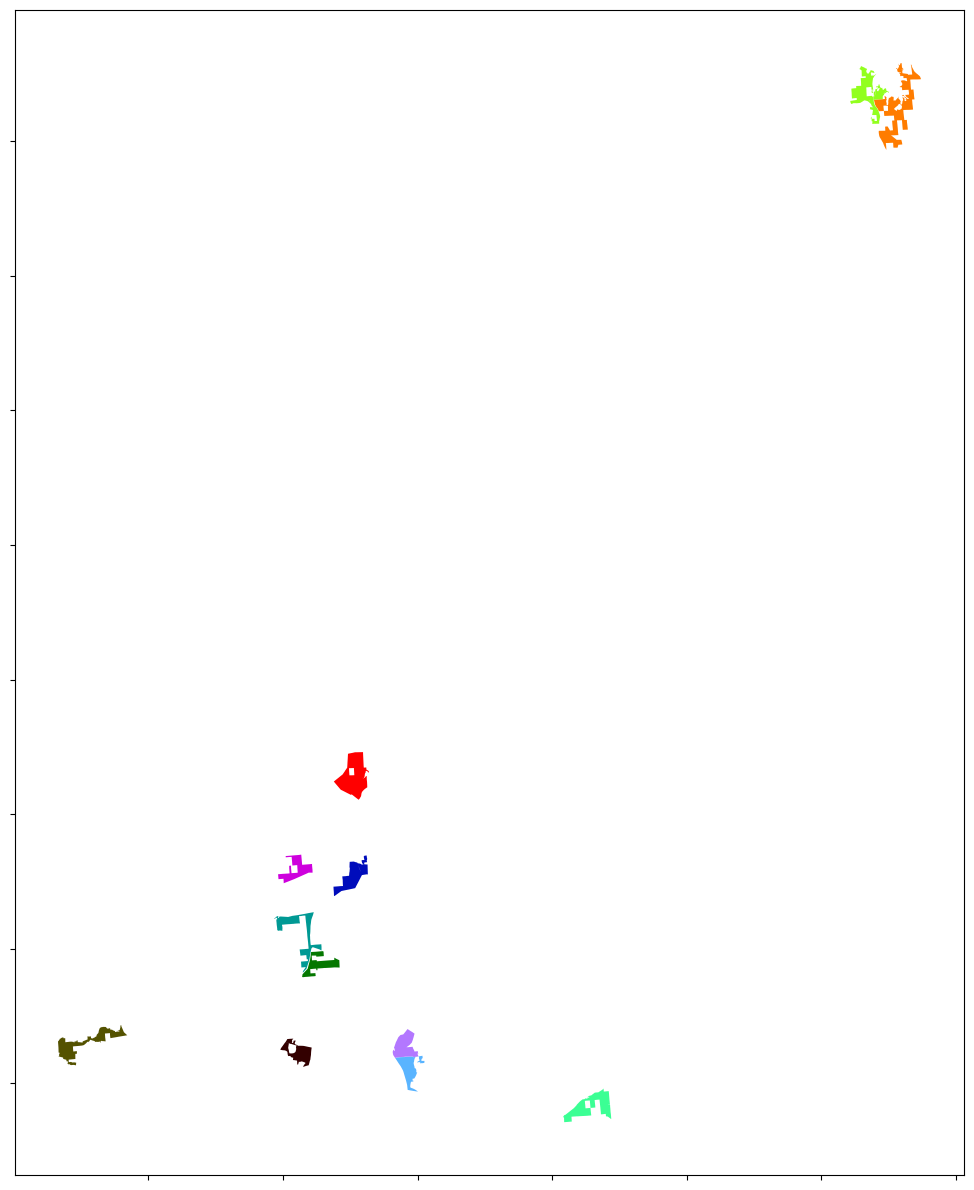

In [161]:
ax = parcel_gdf.plot(
    column="parcel_id",
    cmap=ListedColormap(generate_colormap(len(parcel_gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "parcels_initial.png",
    dpi=300,
    bbox_inches="tight",
)

In [162]:
parcel_gdf

,parcel_id,geometry,Name,village_name,Original Parcel Area (ha),Khasra Count,Khasra IDs,Closest Parcel Distance (m),Closest Parcel ID
0,ASKN_10,"POLYGON ((3725916.194 60657.421, 3725897.025 6...",1077,Akhai tappa,52.823928,10,"['400102000412341077', '400102000412341081/1',...",2308.93,ASKN_12
1,ASKN_11,"POLYGON ((3717087.843 60688.980, 3717074.090 6...",494,Sonera,88.375491,42,"['40010200039230494', '40010200039230491', '40...",5711.66,ASKN_10
2,ASKN_12,"POLYGON ((3726040.702 64081.087, 3726053.017 6...",2/1,Kachnar,51.409013,11,"['400102000432672/1', '400102000432673/1', '40...",17.01,ASKN_13
3,ASKN_13,"POLYGON ((3725956.812 64891.392, 3725958.077 6...",71,Mahua kheda kachnar,73.976851,20,"['4001020004425471', '40010200043265443/2', '4...",17.01,ASKN_12
4,ASKN_14,"POLYGON ((3727131.284 67112.820, 3727066.636 6...",398,Jatoli,71.997394,10,"['40010200046212398', '40010200046212399', '40...",935.06,ASKN_15
5,ASKN_15,"POLYGON ((3725024.918 67430.655, 3725024.583 6...",527,Kariya rai,54.498329,19,"['40010200036238527', '40010200036238528', '40...",935.06,ASKN_14
6,ASKN_16,"POLYGON ((3727550.217 70733.393, 3727523.380 7...",82,Dangahi,123.236166,30,"['4001010004820082', '4001010004820081', '4001...",2088.44,ASKN_14
7,ASKN_48,"POLYGON ((3747418.788 94688.734, 3747413.474 9...",211,Lahadpur,160.078510,55,"['40030200037124211', '40030200037124213', '40...",0.04,ASKN_49
8,ASKN_49,"POLYGON ((3746083.997 96470.374, 3746077.028 9...",354,Lahadpur,95.573637,95,"['40030200037124354', '40030200037124355', '40...",0.04,ASKN_48
9,ASKN_7,"POLYGON ((3735727.809 58611.972, 3735728.973 5...",72,Mahu alampur,88.842806,21,"['4001020006328172', '4001020006328171', '4001...",5474.03,ASKN_8


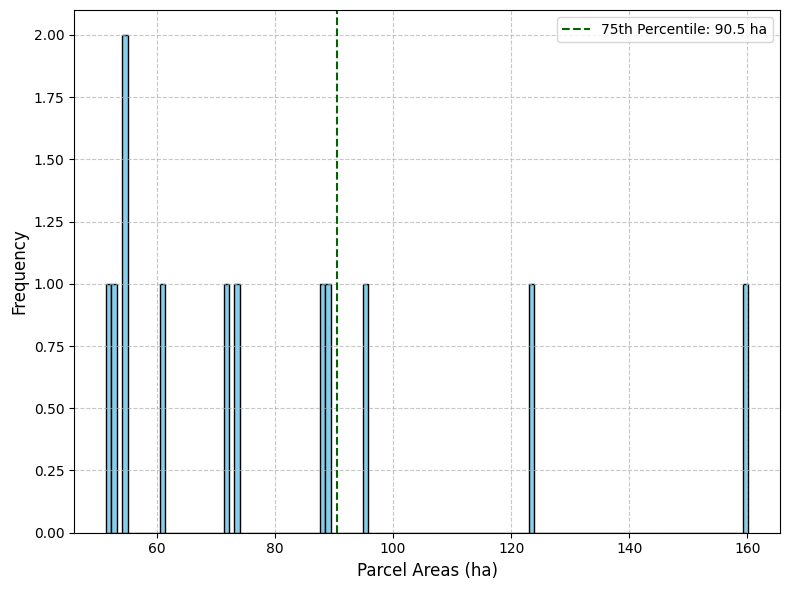

In [163]:
# Plotting the histogram of intra-distances
f, ax = plt.subplots(1, 1, figsize=(8, 6))
parcel_gdf["Original Parcel Area (ha)"].hist(
    ax=ax, bins=120, color="skyblue", edgecolor="black"
)

# add lines for percentile
percentile_area = round(parcel_gdf["Original Parcel Area (ha)"].quantile(0.75), 1)
ax.axvline(
    percentile_area,
    color="darkgreen",
    linestyle="--",
    label=f"75th Percentile: {percentile_area} ha",
)

ax.legend()
# ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
ax.set_xlabel("Parcel Areas (ha)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR
    / "parcels_initial_area_histogram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [164]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [95]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3
import shapely

#### Download rooftop data
Get the ID of the level 6 S2 Cell that this area sits inside

In [96]:
s2_ids = []

for index, row in parcel_gdf.to_crs(4326).iterrows():
    lat = row["geometry"].centroid.y
    lon = row["geometry"].centroid.x
    s2_cell_id = lat_lon_to_cell_id(lat=lat, lon=lon, level=6)
        
    s2_ids.append(s2_cell_id)

s2_ids = list(set(s2_ids))


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [97]:
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print("File already exists")
    else:
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        s3.download_file(
            "vida",
            f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
            str(s2_rooftops_path),
        )
        print("File downloaded.")

File downloaded.


#### Load and process rooftop data

In [98]:
rooftop_gdf_list = []
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

#### Filter to only rooftops that overlap the parcels

In [99]:
subset_rooftops_gdf = rooftop_gdf.sjoin(
    parcel_gdf, how="inner", predicate="intersects"
).drop(columns=["index_right"])
subset_rooftops_gdf.drop(
    columns=parcel_gdf.columns.drop("geometry"), inplace=True
)

In [100]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, parcel_gdf, how="intersection"
)

#### Settlements - auto or manual

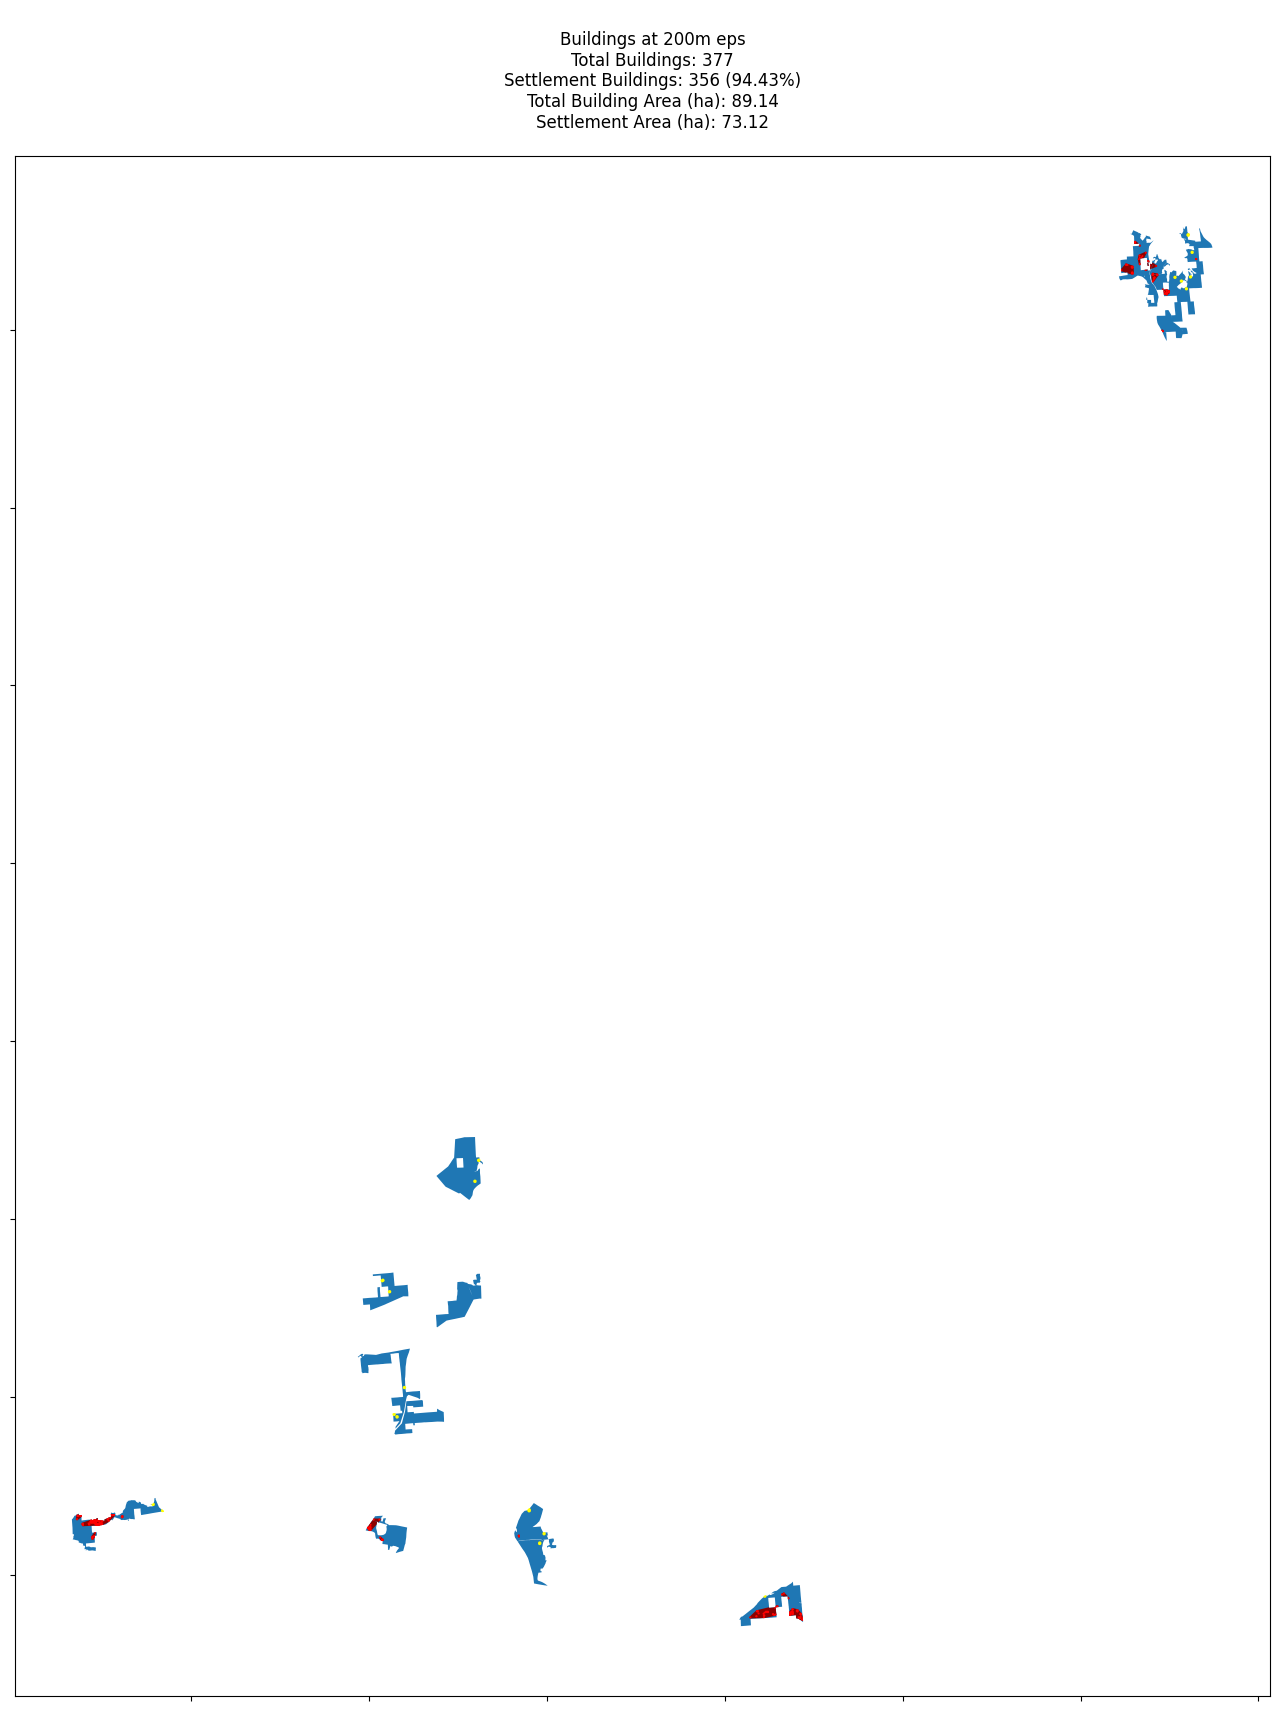

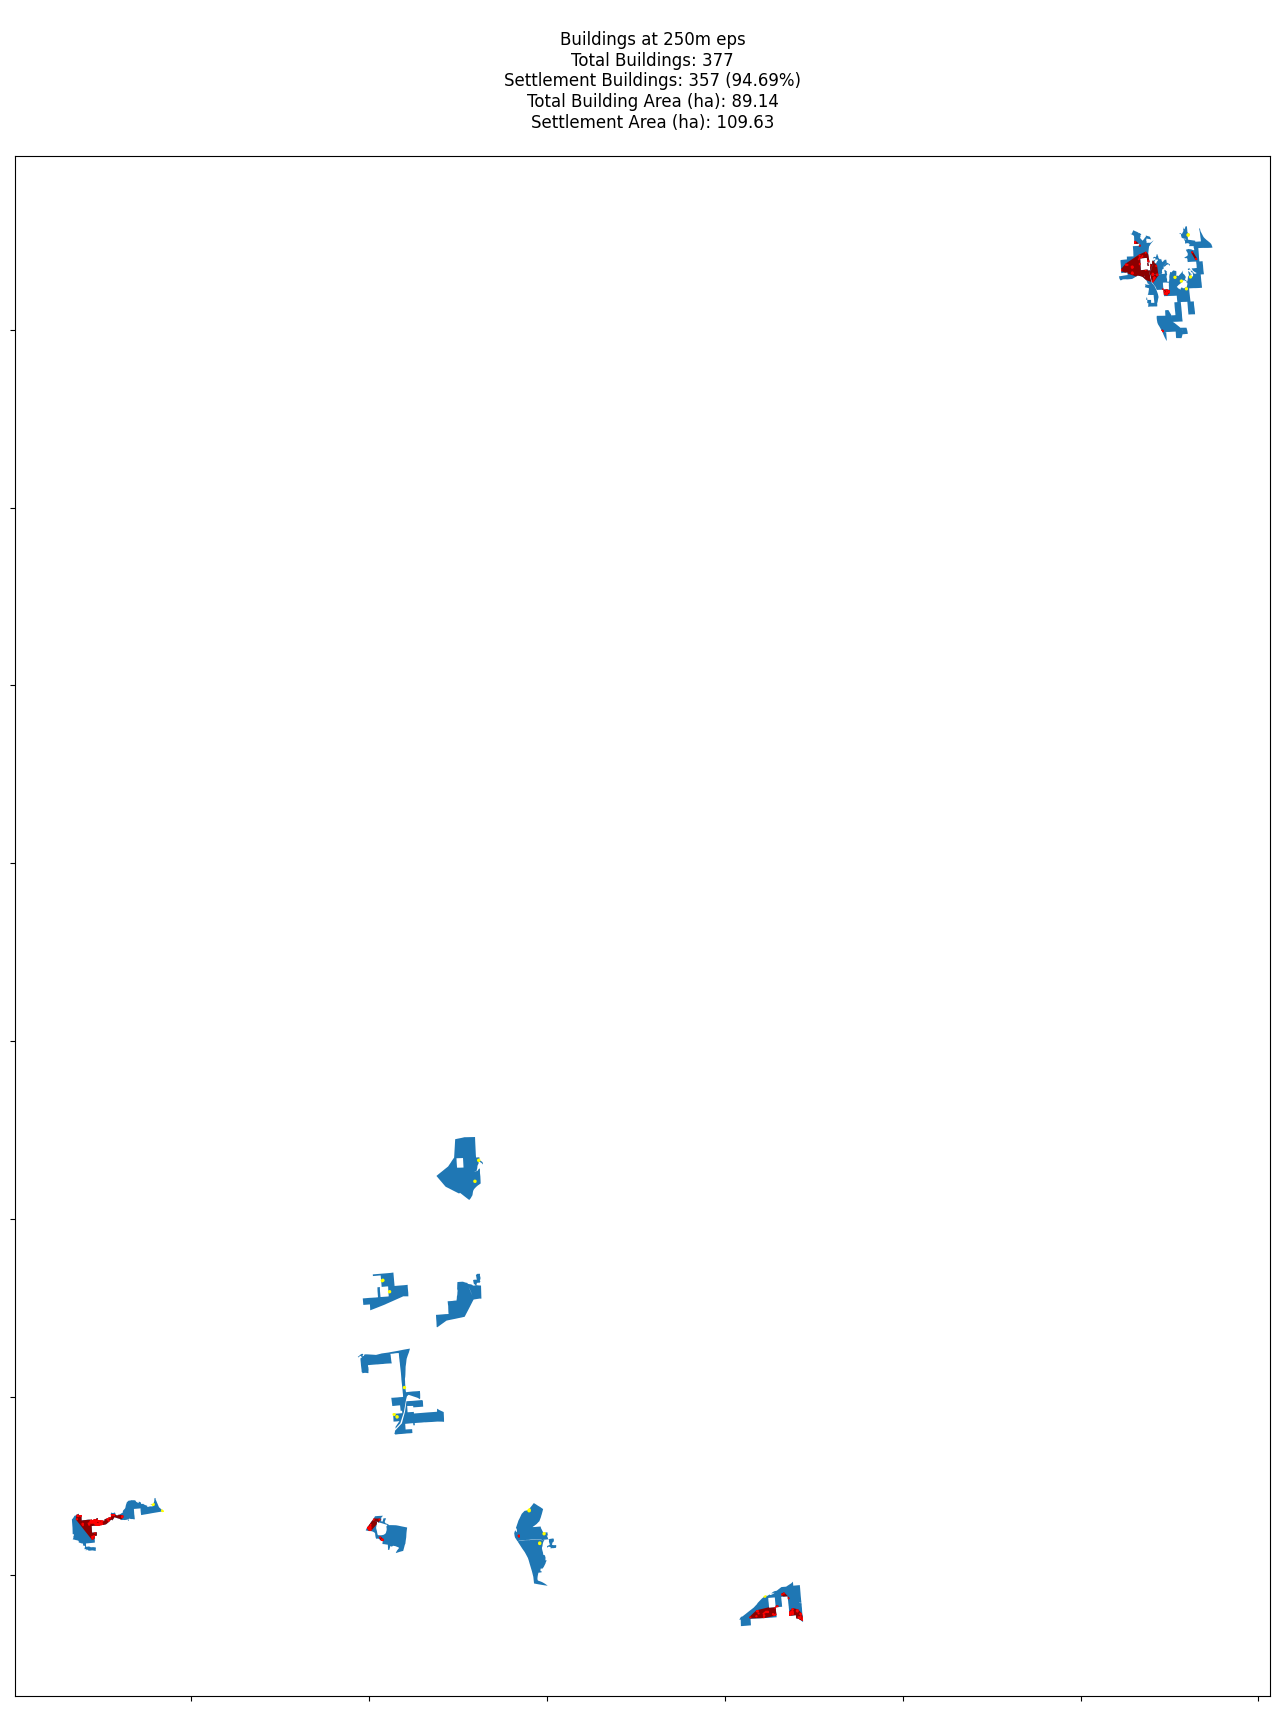

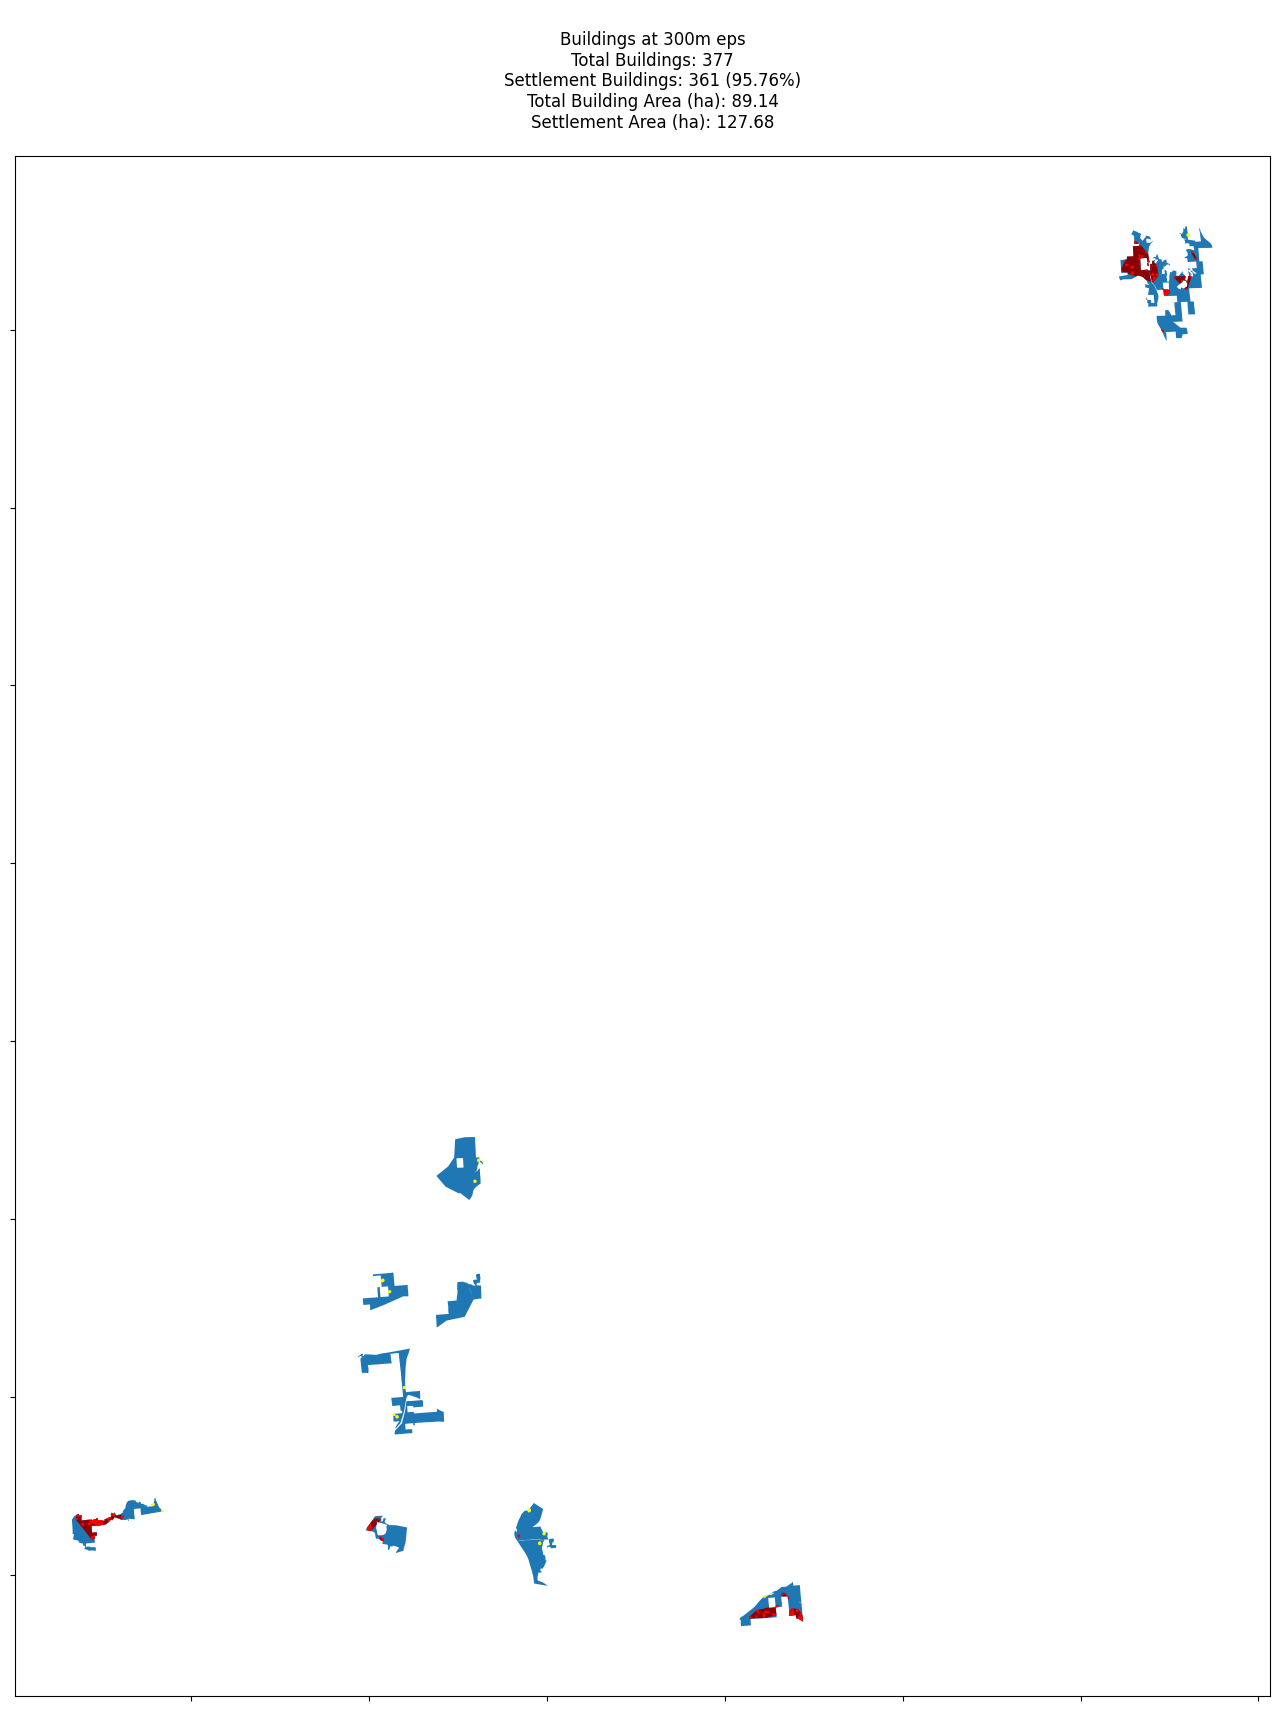

In [101]:
# AUTOMATIC
from sklearn.cluster import DBSCAN

for eps in [200, 250, 300]:
    clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
    building_centroids = buildings_overlap_gdf.geometry.centroid
    X = np.array(list(zip(building_centroids.x, building_centroids.y)))
    building_cluster_ids = clusterer.fit_predict(X)
    buildings_overlap_gdf["settlement_id"] = building_cluster_ids

    settlement_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] != -1
    ]
    rogue_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] == -1
    ]

    # get the convex hull of each cluster
    settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
    settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
    settlements_gdf.geometry = settlements_gdf.convex_hull

    # get cutout of the buffered building shapes that overlap parcels
    settlements_gdf = gpd.overlay(settlements_gdf, parcel_gdf, how="intersection")
    settlements_gdf = settlements_gdf[["parcel_id", "settlement_id", "geometry"]]

    # plot
    ax = parcel_gdf.plot(figsize=(20, 20))
    settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
    settlement_buildings_gdf.plot(ax=ax, color="red")
    rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

    # add stats
    total_count = len(buildings_overlap_gdf)
    settlement_count = len(settlement_buildings_gdf)
    perc_settlement_buildings = settlement_count / total_count * 100
    rogue_count = len(rogue_buildings_gdf)
    total_area = buildings_overlap_gdf.area.sum() / 10_000
    settlement_area = settlements_gdf.area.sum() / 10_000
    title = f"""
    Buildings at {eps}m eps
    Total Buildings: {total_count}
    Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
    Total Building Area (ha): {total_area:.2f}
    Settlement Area (ha): {settlement_area:.2f}
    """
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    plt.savefig(
        DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
    )

In [102]:
CHOSEN_EPS = 300
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, parcel_gdf, how="intersection")
settlements_gdf = settlements_gdf[["parcel_id", "settlement_id", "geometry"]]

In [103]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="parcel_id").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="parcel_id").reset_index()

In [104]:
rogue_buildings_overlap_gdf["Unsuitable Area - Isolated Buildings (ha)"] = rogue_buildings_overlap_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["parcel_id", "Unsuitable Area - Isolated Buildings (ha)"]]

In [105]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="parcel_id").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["parcel_id", "Unusable Area - Settlements (ha)"]]

### Landcover (Cropland, Water)

#### Landcover

In [106]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [107]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [108]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

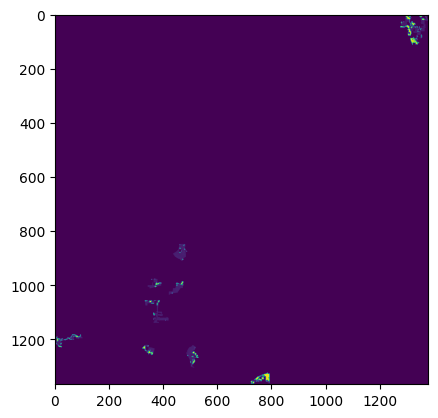

<Axes: >

In [109]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [parcel_gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [110]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [111]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [112]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, parcel_gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [113]:
cropland_overlap_gdf["Unsuitable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["parcel_id", "Unsuitable Area - Cropland (ha)"]]

#### Water

In [114]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [115]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, parcel_gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [116]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["parcel_id", "Unusable Area - Water (ha)"]]

### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [122]:
from pydem.dem_processing import DEMProcessor

In [123]:
def get_steep_shapes(dem_filename):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    # calculate slope and aspect and save to file
    slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
    np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem)
    np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)

    # # OR if precomputed, load files
    # slope_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy")
    # aspect_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy")

    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # Display slope and aspect
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    # slope vis
    ax1.imshow(slope)
    ax1.set_title(f"{dem_filename} - Slope")
    ax2.hist(slope.flatten(), bins=100)
    ax2.set_title("Slope Histogram")
    # aspect vis
    ax3.imshow(aspect)
    ax3.set_title(f"{dem_filename} - Aspect")
    ax4.hist(aspect.flatten(), bins=100)
    ax4.set_title("Aspect Histogram")
    plt.tight_layout()
    plt.show()

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Plot the mask with a binary colormap and correct axes
    x_min = transform[2]
    x_max = x_min + transform[0] * slope_mask.shape[1]
    y_max = transform[5]
    y_min = y_max + transform[4] * slope_mask.shape[0]
    plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
    plt.colorbar(label="Aspect Mask", ax=ax)
    plt.title("Aspect Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    return slope_shapes_gdf

Processing P5_PAN_CD_N24_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Conditioning Elevation: Filling Flats...
Conditioning Elevation: Draining pits along min elevation path...


/Users/amiremami/miniconda3/envs/clustering/lib/python3.11/site-packages/pydem/dem_processing.py:539: UserWarning: Warning 550 pits had no place to drain to in this chunk
  warnings.warn("Warning %d pits had no place to drain to in this "


... done draining pits with maxiter = 300
Starting slope/direction calculation...


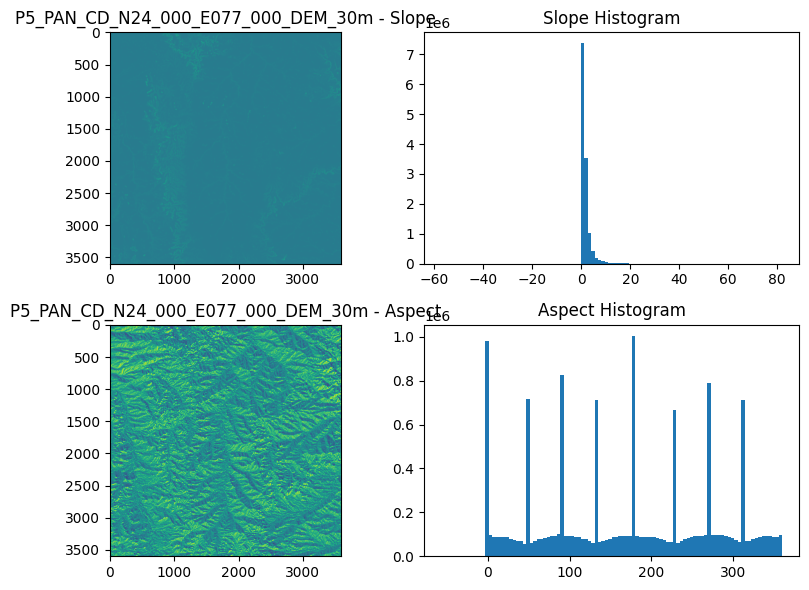

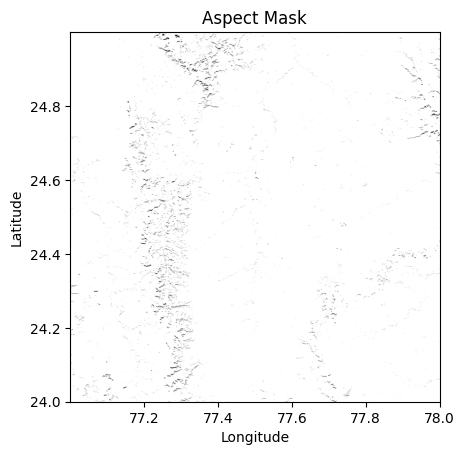

Extracting vector shapes...


In [124]:
dem_filenames = ["P5_PAN_CD_N24_000_E077_000_DEM_30m"] #["cdnf43i", "cdnf43j"] #["cdnf44a"] 

steep_shapes_gdf_list = []
for dem_filename in dem_filenames:
    steep_shapes_gdf = get_steep_shapes(dem_filename)
    steep_shapes_gdf_list.append(steep_shapes_gdf)

In [125]:
slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

In [126]:
slope_overlap_gdf = gpd.overlay(
    slope_shapes_gdf, parcel_gdf, how="intersection", keep_geom_type=False
)
slope_overlap_gdf = slope_overlap_gdf.dissolve(by="parcel_id").reset_index()

<Axes: >

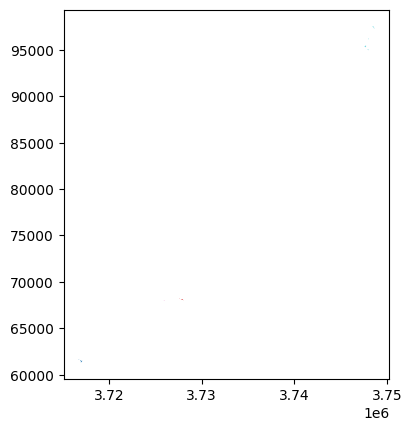

In [127]:
slope_overlap_gdf.plot(column="parcel_id")

In [128]:
slope_overlap_gdf["Unsuitable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["parcel_id", "Unsuitable Area - Slope (ha)"]]

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [165]:
parcel_gdf_for_unusable_area = parcel_gdf.copy()
selected_parcel_id_list = parcel_gdf_for_unusable_area["parcel_id"].unique()
selected_foldername = "Layered"

#### Plots

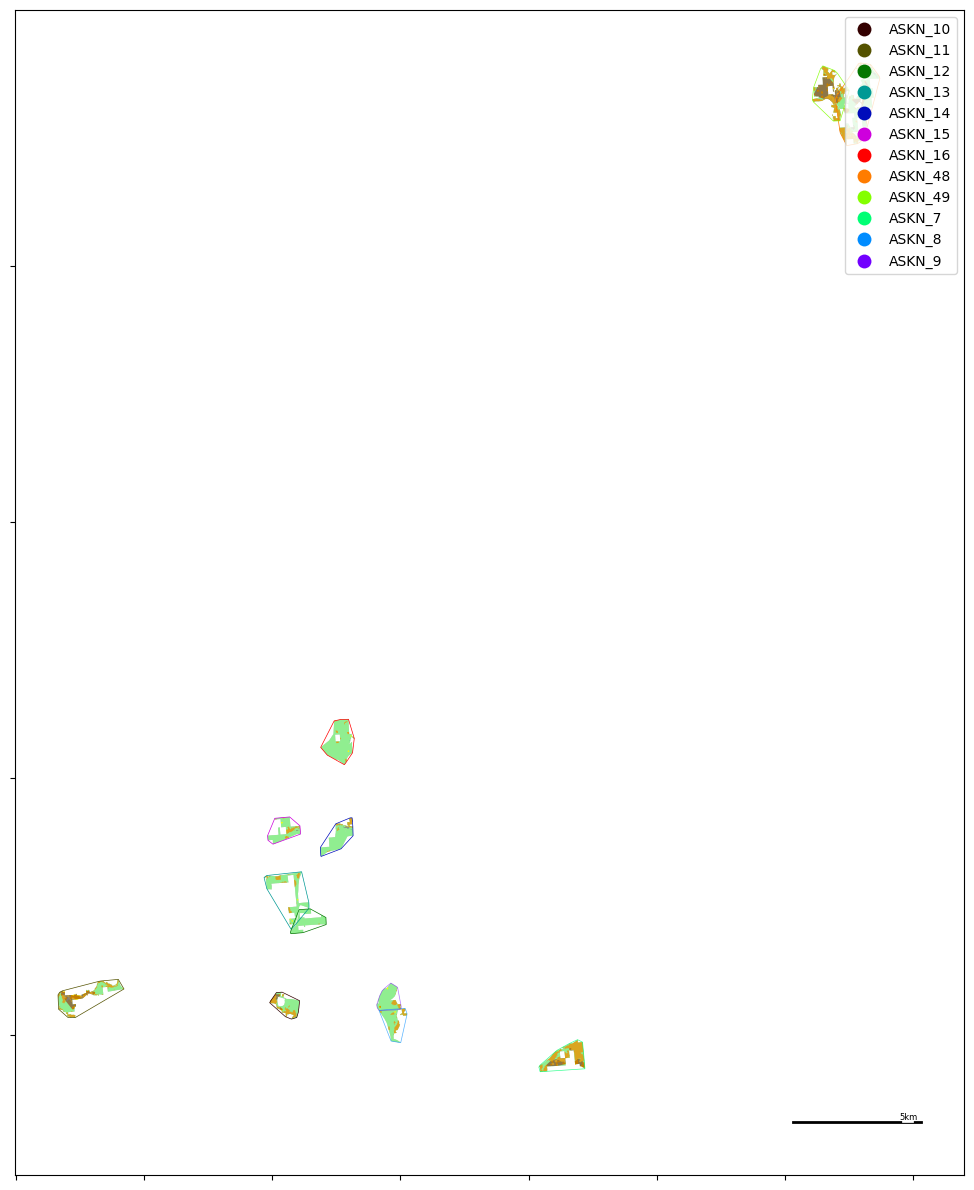

In [136]:
FOLDER_PATH = OUTPUT_DATA_DIR / LOCATION
FOLDER_PATH.mkdir(parents=True, exist_ok=True)

# add colored outline based on parcel_id

ax = parcel_gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
parcel_gdf_for_unusable_area.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Parcel",
)
boundary_gdf = gpd.GeoDataFrame(
    parcel_gdf_for_unusable_area.convex_hull.boundary, columns=["geometry"]
)
boundary_gdf["parcel_id"] = parcel_gdf_for_unusable_area["parcel_id"]
boundary_gdf.plot(
    ax=ax,
    column="parcel_id",
    linewidth=0.5,
    cmap=ListedColormap(
        generate_colormap(len(parcel_gdf_for_unusable_area["parcel_id"].unique()))
    ),
    legend=True,
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 550, xmax - 450],
    [ymin + 150, ymin + 150],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 100, "5km", fontsize=6, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["parcel_id"].isin(selected_parcel_id_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["parcel_id"].isin(selected_parcel_id_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.5, label="Settlements")

water_overlap_gdf[
    water_overlap_gdf["parcel_id"].isin(selected_parcel_id_list)
].plot(ax=ax, color=WATER_COLOR, label="Water")

cropland_overlap_gdf[
    cropland_overlap_gdf["parcel_id"].isin(selected_parcel_id_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[
    slope_overlap_gdf["parcel_id"].isin(selected_parcel_id_list)
].plot(ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg")

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "parcels_larger_than_50ha_w_layers.png", dpi=300, bbox_inches="tight"
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_27063/3143856560.py:141: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_27063/3143856560.py:141: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_27063/3143856560.py:141: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_27063/3143856560.py:136: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.5,

KeyboardInterrupt: 

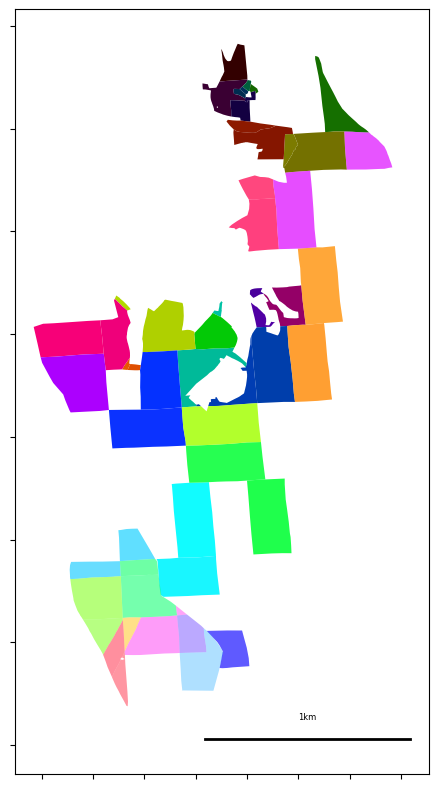

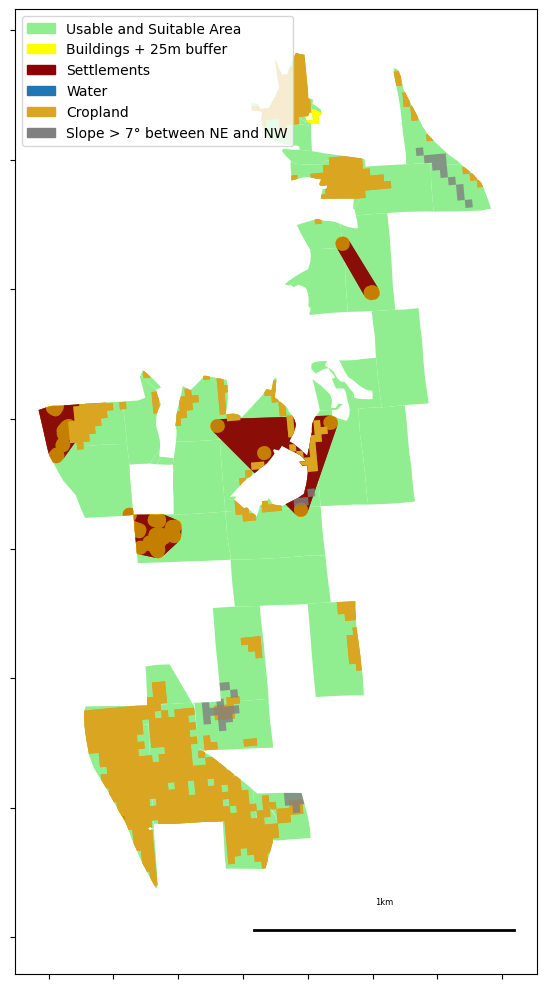

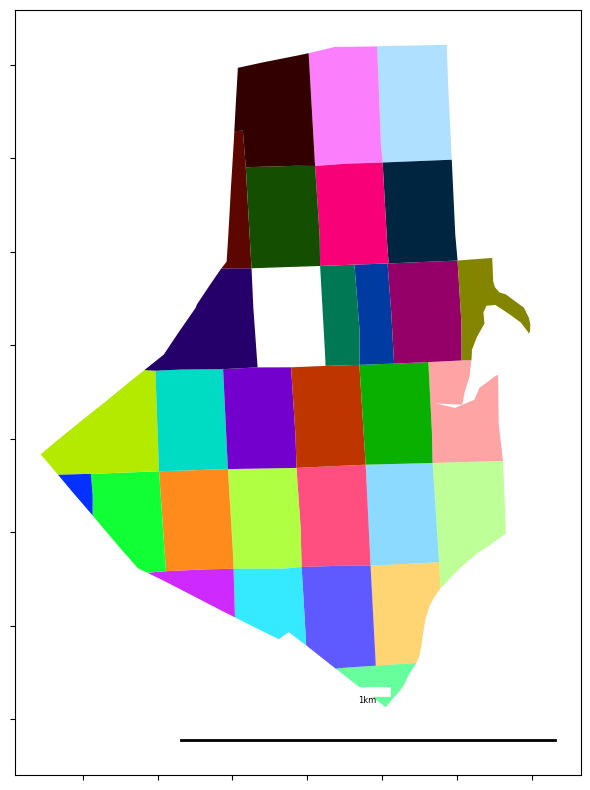

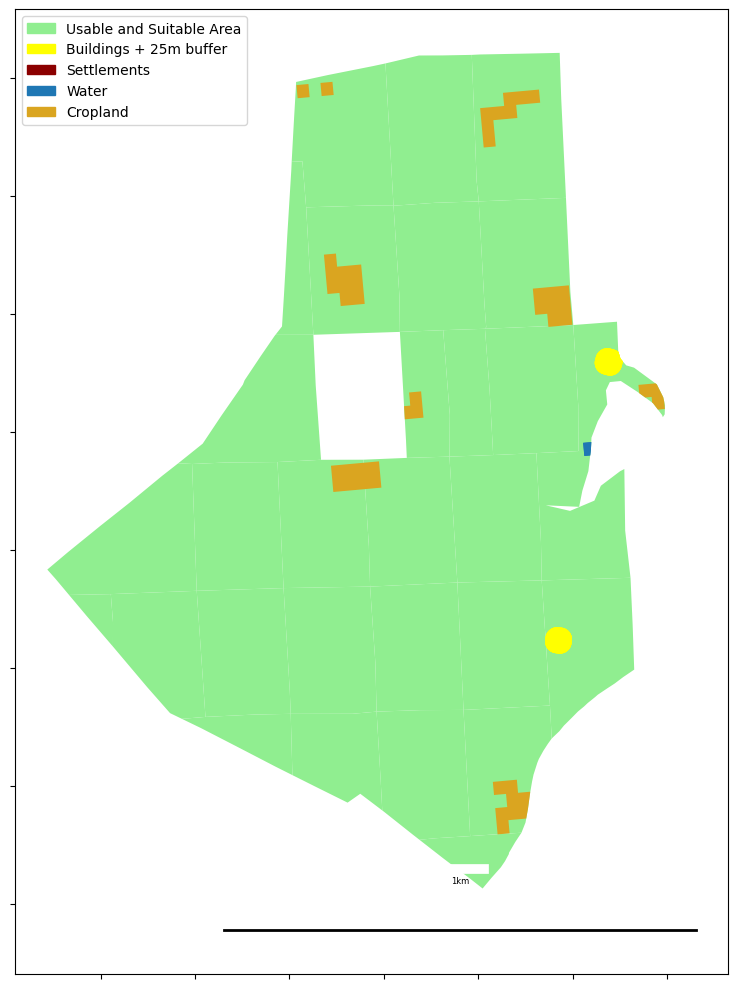

In [137]:
import matplotlib.patches as mpatches

for CHOSEN_PARCEL_ID in selected_parcel_id_list:
    FOLDER_PATH = (
        OUTPUT_DATA_DIR
        / LOCATION
        / "Individual Parcels"
        / selected_foldername
        / CHOSEN_PARCEL_ID
    )
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)

    # # 1. Histogram of intra-distances
    # subset_intra_distances_df = intra_distances_df[
    #     intra_distances_df["parcel_id"] == CHOSEN_PARCEL_ID
    # ]

    # f, ax = plt.subplots(1, 1, figsize=(8, 6))
    # subset_intra_distances_df["raw_distances"].hist(
    #     ax=ax, bins=25, color="skyblue", edgecolor="black"
    # )

    # # add lines for average and 75% percentile
    # avg_distance = subset_intra_distances_df[
    #     "Inter-Khasra Distance Average (m)"
    # ].values[0]
    # percentile_75th_distance = subset_intra_distances_df[
    #     "Inter-Khasra Distance 75th Percentile (m)"
    # ].values[0]

    # ax.axvline(
    #     avg_distance,
    #     color=BACKGROUND_COLOR,
    #     linestyle="--",
    #     label=f"Average: {avg_distance}m",
    # )
    # ax.axvline(
    #     percentile_75th_distance,
    #     color="darkgreen",
    #     linestyle="--",
    #     label=f"75th Percentile: {percentile_75th_distance}m",
    # )

    # ax.legend()
    # # ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
    # ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
    # ax.set_ylabel("Frequency", fontsize=12)
    # ax.grid(True, linestyle="--", alpha=0.7)

    # plt.tight_layout()
    # plt.savefig(
    #     FOLDER_PATH / "intra_distances_histogram.png", dpi=300, bbox_inches="tight"
    # )
    # plt.show()

    # 2. Khasra-level plot
    ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
        column="khasra_id",
        cmap=ListedColormap(
            generate_colormap(len(gdf_with_parcel_id["khasra_id"].unique()))
        ),
        figsize=(8, 8),
    )

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
    )
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
    )
    ax.plot(
        [xmax - 550, xmax - 450],
        [ymin + 130, ymin + 130],
        color="white",
        linewidth=7,
        linestyle="-",
    )
    ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

    plt.tight_layout()
    plt.savefig(FOLDER_PATH / "khasras.png", dpi=300, bbox_inches="tight")

    # 3. Parcel + Layers plots
    ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
        color=BACKGROUND_COLOR,
        label="Original Parcel",
        figsize=(10, 10),
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
    )
    ax.plot(
        [xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
    )
    ax.plot(
        [xmax - 550, xmax - 450],
        [ymin + 130, ymin + 130],
        color="white",
        linewidth=7,
        linestyle="-",
    )
    ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

    handles = []
    for i in range(5):
        handles.append(
            mpatches.Patch(
                color=BACKGROUND_COLOR,
                label="Usable and Suitable Area",
            )
        )
        if i >= 0:
            buildings_overlap_gdf[
                buildings_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
            LAYERS = "Buildings"
            handles.append(
                mpatches.Patch(color=BUILDING_COLOR, label="Buildings + 25m buffer")
            )

        if i >= 1:
            settlements_overlap_gdf[
                settlements_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.5, label="Settlements")
            LAYERS = "Buildings, Settlements"
            handles.append(mpatches.Patch(color=SETTLEMENT_COLOR, label="Settlements"))

        if i >= 2:
            water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color=WATER_COLOR, label="Water"
            )
            LAYERS = "Buildings, Settlements, Water"
            handles.append(mpatches.Patch(color=WATER_COLOR, label="Water"))

        if i >= 3:
            cropland_overlap_gdf[
                cropland_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
            LAYERS = "Buildings, Settlements, Water, Cropland"
            handles.append(mpatches.Patch(color=CROPLAND_COLOR, label="Cropland"))

        if i >= 4:
            slope_overlap_gdf[slope_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
            )
            LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
            handles.append(
                mpatches.Patch(color=SLOPE_COLOR, label="Slope > 7° between NE and NW")
            )

        ax.legend(handles=handles, loc="upper left")
        plt.tight_layout()
        plt.savefig(
            FOLDER_PATH / f"Layers - {LAYERS}.png", dpi=300, bbox_inches="tight"
        )
        handles = []

#### Calculate Areas

##### Cut out unusable

In [166]:
output_parcel_gdf = parcel_gdf_for_unusable_area.copy()

# cut out water
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out settlements
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [167]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_parcel_gdf.area / 10_000
# unusable area
output_parcel_gdf["Unusable Area (ha)"] = (
    output_parcel_gdf["Original Parcel Area (ha)"] - usable_area_series
)
# usable area
output_parcel_gdf["Usable Area (ha)"] = usable_area_series

In [168]:
output_parcel_gdf

,parcel_id,geometry,Name,village_name,Original Parcel Area (ha),Khasra Count,Khasra IDs,Closest Parcel Distance (m),Closest Parcel ID,Unusable Area (ha),Usable Area (ha)
0,ASKN_10,"MULTIPOLYGON (((3725897.025 60652.240, 3725884...",1077,Akhai tappa,52.823928,10,"['400102000412341077', '400102000412341081/1',...",2308.93,ASKN_12,7.178259,45.645668
1,ASKN_11,"MULTIPOLYGON (((3717074.090 60700.235, 3717064...",494,Sonera,88.375491,42,"['40010200039230494', '40010200039230491', '40...",5711.66,ASKN_10,27.933689,60.441802
2,ASKN_12,"POLYGON ((3726040.702 64081.087, 3726053.017 6...",2/1,Kachnar,51.409013,11,"['400102000432672/1', '400102000432673/1', '40...",17.01,ASKN_13,0.000000,51.409013
3,ASKN_13,"POLYGON ((3725956.812 64891.392, 3725958.077 6...",71,Mahua kheda kachnar,73.976851,20,"['4001020004425471', '40010200043265443/2', '4...",17.01,ASKN_12,0.000000,73.976851
4,ASKN_14,"POLYGON ((3727131.284 67112.820, 3727066.636 6...",398,Jatoli,71.997394,10,"['40010200046212398', '40010200046212399', '40...",935.06,ASKN_15,0.000000,71.997394
5,ASKN_15,"POLYGON ((3725024.918 67430.655, 3725024.583 6...",527,Kariya rai,54.498329,19,"['40010200036238527', '40010200036238528', '40...",935.06,ASKN_14,0.000000,54.498329
6,ASKN_16,"POLYGON ((3727523.380 70714.596, 3727454.041 7...",82,Dangahi,123.236166,30,"['4001010004820082', '4001010004820081', '4001...",2088.44,ASKN_14,0.042126,123.194040
7,ASKN_48,"MULTIPOLYGON (((3747413.474 94690.117, 3747398...",211,Lahadpur,160.078510,55,"['40030200037124211', '40030200037124213', '40...",0.04,ASKN_49,14.740346,145.338164
8,ASKN_49,"MULTIPOLYGON (((3746077.028 96498.698, 3746073...",354,Lahadpur,95.573637,95,"['40030200037124354', '40030200037124355', '40...",0.04,ASKN_48,50.843331,44.730306
9,ASKN_7,"MULTIPOLYGON (((3735728.973 58579.483, 3735729...",72,Mahu alampur,88.842806,21,"['4001020006328172', '4001020006328171', '4001...",5474.03,ASKN_8,26.602467,62.240339


##### Drop khasras that are not usable at all

In [169]:
pre_usable_khasras_gdf = gdf_with_parcel_id.sjoin(
    parcel_gdf_for_unusable_area[["geometry", "Khasra Count"]], 
    how="inner", 
    predicate="intersects"
).drop(columns=["index_right", "Khasra Count"])

In [170]:
chosen_parcels_usable_khasras_gdf = pre_usable_khasras_gdf.sjoin(
    output_parcel_gdf[["geometry", "Khasra Count"]], 
    how="inner", 
    predicate="intersects"
).drop(columns=["index_right", "Khasra Count"])

khasra_id_list = chosen_parcels_usable_khasras_gdf["khasra_id"].unique()
chosen_parcels_unusable_khasras_gdf = pre_usable_khasras_gdf[
    ~pre_usable_khasras_gdf["khasra_id"].isin(khasra_id_list)
]

In [171]:
# pre_usable_khasras_gdf = gdf_with_parcel_id[gdf_with_parcel_id.intersects(parcel_gdf_for_unusable_area.unary_union)]
# usable_khasra_filter = pre_usable_khasras_gdf.intersects(output_parcel_gdf.unary_union)
# chosen_parcels_usable_khasras_gdf = pre_usable_khasras_gdf[usable_khasra_filter]
# chosen_parcels_unusable_khasras_gdf = pre_usable_khasras_gdf[~usable_khasra_filter]

In [172]:
## Usable khasras
# add how many khasras are inside
usable_khasra_counts_series = chosen_parcels_usable_khasras_gdf.groupby("parcel_id")["khasra_id"].count()
output_parcel_gdf["Khasra Count"] = output_parcel_gdf["parcel_id"].map(usable_khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
usable_khasra_ids_series = chosen_parcels_usable_khasras_gdf.groupby("parcel_id")["khasra_id"].apply(list).astype(str)
output_parcel_gdf["Khasra IDs"] = output_parcel_gdf["parcel_id"].map(usable_khasra_ids_series)

## Unusable khasras
unsuable_khasra_counts_series = chosen_parcels_unusable_khasras_gdf.groupby("parcel_id")["khasra_id"].count()
output_parcel_gdf["Unusable Khasra Count"] = output_parcel_gdf["parcel_id"].map(unsuable_khasra_counts_series)
# add names of all khasras that fall inside each parcel but are under unusable layers
unsuable_khasra_ids_series = chosen_parcels_unusable_khasras_gdf.groupby("parcel_id")["khasra_id"].apply(list).astype(str)
output_parcel_gdf["Unusable Khasra IDs"] = output_parcel_gdf["parcel_id"].map(unsuable_khasra_ids_series)

In [173]:
output_parcel_gdf = output_parcel_gdf[
    [
        "parcel_id",
        "geometry",
        "village_name",
        "Original Parcel Area (ha)",
        "Closest Parcel Distance (m)",
        "Closest Parcel ID",
        "Khasra Count",
        "Khasra IDs",
        "Unusable Khasra Count",
        "Unusable Khasra IDs",
        "Unusable Area (ha)",
        "Usable Area (ha)",
    ]
]

In [174]:
output_parcel_gdf

,parcel_id,geometry,village_name,Original Parcel Area (ha),Closest Parcel Distance (m),Closest Parcel ID,Khasra Count,Khasra IDs,Unusable Khasra Count,Unusable Khasra IDs,Unusable Area (ha),Usable Area (ha)
0,ASKN_10,"MULTIPOLYGON (((3725897.025 60652.240, 3725884...",Akhai tappa,52.823928,2308.93,ASKN_12,10,"['400102000412341077', '400102000412341081/1',...",NaN,NaN,7.178259,45.645668
1,ASKN_11,"MULTIPOLYGON (((3717074.090 60700.235, 3717064...",Sonera,88.375491,5711.66,ASKN_10,37,"['40010200039230494', '40010200039230491', '40...",5.0,"['40010200039230921', '40010200039230967', '40...",27.933689,60.441802
2,ASKN_12,"POLYGON ((3726040.702 64081.087, 3726053.017 6...",Kachnar,51.409013,17.01,ASKN_13,11,"['400102000432672/1', '400102000432673/1', '40...",NaN,NaN,0.000000,51.409013
3,ASKN_13,"POLYGON ((3725956.812 64891.392, 3725958.077 6...",Mahua kheda kachnar,73.976851,17.01,ASKN_12,20,"['4001020004425471', '40010200043265443/2', '4...",NaN,NaN,0.000000,73.976851
4,ASKN_14,"POLYGON ((3727131.284 67112.820, 3727066.636 6...",Jatoli,71.997394,935.06,ASKN_15,10,"['40010200046212398', '40010200046212399', '40...",NaN,NaN,0.000000,71.997394
5,ASKN_15,"POLYGON ((3725024.918 67430.655, 3725024.583 6...",Kariya rai,54.498329,935.06,ASKN_14,19,"['40010200036238527', '40010200036238528', '40...",NaN,NaN,0.000000,54.498329
6,ASKN_16,"POLYGON ((3727523.380 70714.596, 3727454.041 7...",Dangahi,123.236166,2088.44,ASKN_14,30,"['4001010004820082', '4001010004820081', '4001...",NaN,NaN,0.042126,123.194040
7,ASKN_48,"MULTIPOLYGON (((3747413.474 94690.117, 3747398...",Lahadpur,160.078510,0.04,ASKN_49,55,"['40030200037124211', '40030200037124213', '40...",NaN,NaN,14.740346,145.338164
8,ASKN_49,"MULTIPOLYGON (((3746077.028 96498.698, 3746073...",Lahadpur,95.573637,0.04,ASKN_48,81,"['40030200037124354', '40030200037124355', '40...",14.0,"['4003020003712738', '40030200037127143', '400...",50.843331,44.730306
9,ASKN_7,"MULTIPOLYGON (((3735728.973 58579.483, 3735729...",Mahu alampur,88.842806,5474.03,ASKN_8,21,"['4001020006328172', '4001020006328171', '4001...",NaN,NaN,26.602467,62.240339


In [175]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_usable",
    formats=["parquet", "kml", "csv"],
)

#### Save centroids for displaying ID on the map

In [176]:
gdf_centroids_with_merged_parcel_id = gdf_with_parcel_id.copy()
gdf_centroids_with_merged_parcel_id["geometry"] = gdf_centroids_with_merged_parcel_id.centroid

In [177]:
gdf_centroids_with_merged_parcel_id

,geometry,Name,khasra_id,village_name,parcel_id,Khasra Area (ha)
0,POINT (3735599.050 58826.761),72,4001020006328172,Mahu alampur,ASKN_7,4.133978
1,POINT (3735584.510 58653.702),71,4001020006328171,Mahu alampur,ASKN_7,5.147309
2,POINT (3736348.503 58934.915),50,4001020006328150,Mahu alampur,ASKN_7,5.064021
3,POINT (3736163.978 58918.643),49,4001020006328149,Mahu alampur,ASKN_7,5.273544
4,POINT (3735983.613 58907.466),48,4001020006328148,Mahu alampur,ASKN_7,4.648754
...,...,...,...,...,...,...
342,POINT (3746928.636 95796.741),354,40030200037127354,Shahpur,ASKN_49,0.871232
343,POINT (3746876.983 95772.518),355,40030200037127355,Shahpur,ASKN_49,0.050876
344,POINT (3746942.116 95700.984),399,40030200037127399,Shahpur,ASKN_49,0.880724
345,POINT (3747030.001 95704.673),400,40030200037127400,Shahpur,ASKN_49,0.926892


In [179]:
save_shapefiles(
    gdf_centroids_with_merged_parcel_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasra_centroids_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unsuitable

In [180]:
# cut out rogue buildings
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out slopes
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out cropland
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [181]:
output_parcel_gdf["Usable and Suitable Area (ha)"] = output_parcel_gdf.area / 10_000
output_parcel_gdf["Usable but Unsuitable Area (ha)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    - output_parcel_gdf["Usable and Suitable Area (ha)"]
)

In [182]:
# percentages
output_parcel_gdf["Unusable Area (%)"] = (
    output_parcel_gdf["Unusable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable Area (%)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable and Suitable Area (%)"] = (
    output_parcel_gdf["Usable and Suitable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)
output_parcel_gdf["Usable but Unsuitable Area (%)"] = (
    output_parcel_gdf["Usable but Unsuitable Area (ha)"]
    / output_parcel_gdf["Original Parcel Area (ha)"]
    * 100
)

In [183]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="parcel_id", how="outer").fillna(0)
output_parcel_gdf = output_parcel_gdf.merge(all_unusable_area_cols_df, on="parcel_id", how="left").fillna(0)

output_parcel_gdf["village_name"] = output_parcel_gdf["village_name"].astype(str)

In [185]:
source_parcel_id = "ASKN_12"
source_geom = output_parcel_gdf[output_parcel_gdf["parcel_id"] == source_parcel_id]
distances_to_source = output_parcel_gdf.geometry.apply(lambda x: source_geom.distance(x))

distances_to_source.columns = [f"Distance to {source_parcel_id} (m)"]
output_parcel_gdf = output_parcel_gdf.merge(
    distances_to_source, left_index=True, right_index=True
)

In [186]:
# reorder columns
output_parcel_gdf = output_parcel_gdf[
    [
        "parcel_id",
        "geometry",
        "village_name",
        "Khasra Count",
        "Khasra IDs",
        "Unusable Khasra Count",
        "Unusable Khasra IDs",
        "Original Parcel Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Suitable Area (ha)",
        "Usable but Unsuitable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Suitable Area (%)",
        "Usable but Unsuitable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unsuitable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unsuitable Area - Cropland (ha)",
        "Unsuitable Area - Slope (ha)",
        "Closest Parcel Distance (m)",
        "Closest Parcel ID",
        f"Distance to {source_parcel_id} (m)",
    ]
]

In [189]:
output_parcel_gdf.fillna(0, inplace=True)

In [193]:
output_parcel_gdf["Khasra IDs"] = output_parcel_gdf["Khasra IDs"].astype(str)
output_parcel_gdf["Unusable Khasra IDs"] = output_parcel_gdf["Unusable Khasra IDs"].astype(str)

In [194]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_usable_suitable",
    formats=["parquet", "kml", "csv"],
)

## Save individual layers

In [195]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["parcel_id"].isin(selected_parcel_id_list),
        [
            "parcel_id",
            "geometry",
            "Unsuitable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["parcel_id"].isin(selected_parcel_id_list),
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["parcel_id"].isin(selected_parcel_id_list),
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["parcel_id"].isin(selected_parcel_id_list),
        [
            "parcel_id",
            "geometry",
            "Unsuitable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["parcel_id"].isin(selected_parcel_id_list),
        [
            "parcel_id",
            "geometry",
            "Unsuitable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "slopes",
    formats=["kml"],
)